In [ ]:
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [ ]:
url = '/content/drive/MyDrive/Colab Notebooks/portfolio data/customer_review.csv'
df_covid = pd.read_csv(url)
display(df_covid.head())

,ReviewID,CustomerID,ProductID,ReviewDate,Rating,ReviewText
0,1,77,18,2023-12-23,3,"Average experience, nothing special."
1,2,80,19,2024-12-25,5,The quality is top-notch.
2,3,50,13,2025-01-26,4,Five stars for the quick delivery.
3,4,78,15,2025-04-21,3,"Good quality, but could be cheaper."
4,5,64,2,2023-07-16,3,"Average experience, nothing special."


In [ ]:
url = '/content/drive/MyDrive/Colab Notebooks/portfolio data/customer_review.csv'
customer_review = pd.read_csv(url)


In [ ]:
customer_review.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1363 entries, 0 to 1362
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   ReviewID    1363 non-null   int64 
 1   CustomerID  1363 non-null   int64 
 2   ProductID   1363 non-null   int64 
 3   ReviewDate  1363 non-null   object
 4   Rating      1363 non-null   int64 
 5   ReviewText  1363 non-null   object
dtypes: int64(4), object(2)
memory usage: 64.0+ KB


In [ ]:
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from google.colab import files
nltk.download('vader_lexicon')
sia = SentimentIntensityAnalyzer()

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


In [ ]:
def calculate_sentiment(review):

    if pd.isna(review):
        return 0
    sentiment = sia.polarity_scores(str(review))
    return sentiment['compound']

def categorize_sentiment(score, rating):
    if score > 0.05:
        if rating >= 4: return 'Positive'
        elif rating == 3: return 'Mixed Positive'
        else: return 'Mixed Negative'
    elif score < -0.05:
        if rating <= 2: return 'Negative'
        elif rating == 3: return 'Mixed Negative'
        else: return 'Mixed Positive'
    else:
        if rating >= 4: return 'Positive'
        elif rating <= 2: return 'Negative'
        else: return 'Neutral'

def sentiment_bucket(score):
    if score >= 0.5: return '0.5 to 1.0'
    elif 0.0 <= score < 0.5: return '0.0 to 0.49'
    elif -0.5 <= score < 0.0: return '-0.49 to 0.0'
    else: return '-1.0 to -0.5'


customer_review['SentimentScore'] = customer_review['ReviewText'].apply(calculate_sentiment)
customer_review['SentimentCategory'] = customer_review.apply(
    lambda row: categorize_sentiment(row['SentimentScore'], row['Rating']), axis=1)
customer_review['SentimentBucket'] = customer_review['SentimentScore'].apply(sentiment_bucket)
print(customer_review.head())


   ReviewID  CustomerID  ProductID  ReviewDate  Rating  \
0         1          77         18  2023-12-23       3   
1         2          80         19  2024-12-25       5   
2         3          50         13  2025-01-26       4   
3         4          78         15  2025-04-21       3   
4         5          64          2  2023-07-16       3   

                                 ReviewText  SentimentScore SentimentCategory  \
0   Average  experience,  nothing  special.         -0.3089    Mixed Negative   
1            The  quality  is    top-notch.          0.0000          Positive   
2   Five  stars  for  the  quick  delivery.          0.0000          Positive   
3  Good  quality,  but  could  be  cheaper.          0.2382    Mixed Positive   
4   Average  experience,  nothing  special.         -0.3089    Mixed Negative   

  SentimentBucket  
0    -0.49 to 0.0  
1     0.0 to 0.49  
2     0.0 to 0.49  
3     0.0 to 0.49  
4    -0.49 to 0.0  


In [ ]:

print(customer_review.head())

   ReviewID  CustomerID  ProductID  ReviewDate  Rating  \
0         1          77         18  2023-12-23       3   
1         2          80         19  2024-12-25       5   
2         3          50         13  2025-01-26       4   
3         4          78         15  2025-04-21       3   
4         5          64          2  2023-07-16       3   

                                 ReviewText  SentimentScore SentimentCategory  \
0   Average  experience,  nothing  special.         -0.3089    Mixed Negative   
1            The  quality  is    top-notch.          0.0000          Positive   
2   Five  stars  for  the  quick  delivery.          0.0000          Positive   
3  Good  quality,  but  could  be  cheaper.          0.2382    Mixed Positive   
4   Average  experience,  nothing  special.         -0.3089    Mixed Negative   

  SentimentBucket  
0    -0.49 to 0.0  
1     0.0 to 0.49  
2     0.0 to 0.49  
3     0.0 to 0.49  
4    -0.49 to 0.0  


In [ ]:
customer_review

,ReviewID,CustomerID,ProductID,ReviewDate,Rating,ReviewText,SentimentScore,SentimentCategory,SentimentBucket
0,1,77,18,2023-12-23,3,"Average experience, nothing special.",-0.3089,Mixed Negative,-0.49 to 0.0
1,2,80,19,2024-12-25,5,The quality is top-notch.,0.0000,Positive,0.0 to 0.49
2,3,50,13,2025-01-26,4,Five stars for the quick delivery.,0.0000,Positive,0.0 to 0.49
3,4,78,15,2025-04-21,3,"Good quality, but could be cheaper.",0.2382,Mixed Positive,0.0 to 0.49
4,5,64,2,2023-07-16,3,"Average experience, nothing special.",-0.3089,Mixed Negative,-0.49 to 0.0
...,...,...,...,...,...,...,...,...,...
1358,1359,28,4,2023-05-25,3,Not worth the money.,-0.1695,Mixed Negative,-0.49 to 0.0
1359,1360,58,12,2023-11-13,2,"Average experience, nothing special.",-0.3089,Negative,-0.49 to 0.0
1360,1361,96,15,2023-03-07,5,Customer support was very helpful.,0.6997,Positive,0.5 to 1.0
1361,1362,99,2,2025-12-03,1,Product did not meet my expectations.,0.0000,Negative,0.0 to 0.49


In [ ]:
# Save the DataFrame to an Excel file
customer_review.to_csv('customer_review.csv', index=False)

# Download the saved Excel file
from google.colab import files
files.download('customer_review.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

,new_cases
0,0.0


In [ ]:
mean_new_cases = final_df['new_cases'].mean()
print(f"The mean of new cases in final_df is: {mean_new_cases}")

The mean of new cases in final_df is: 1606.2966340669473


In [ ]:
# Save the DataFrame to a CSV file
final_df.to_csv('final_df.csv', index=False)

# Download the saved CSV file
from google.colab import files
files.download('final_df.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Task
Clean the dataset by following these steps: inspect data, handle missing values, handle duplicates, address inconsistent data, standardize formats, and review outliers. Display the first few rows and data types of the cleaned dataset.

## Inspect data

### Subtask:
Display the first few rows and check data types.


**Reasoning**:
Display the first few rows and check data types of the cleaned dataframe as requested by the subtask.



In [ ]:
display(df.head())
df.info()

,country,date,total_cases,new_cases,new_cases_smoothed,total_cases_per_million,new_cases_per_million,new_cases_smoothed_per_million,total_deaths,new_deaths,...,population,population_density,median_age,life_expectancy,gdp_per_capita,extreme_poverty,diabetes_prevalence,handwashing_facilities,hospital_beds_per_thousand,human_development_index
0,Afghanistan,2020-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,40578847.0,62.215549,16.752001,65.616997,1516.273315,NaN,10.9,48.214695,0.39,NaN
1,Afghanistan,2020-01-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,40578847.0,62.215549,16.752001,65.616997,1516.273315,NaN,10.9,48.214695,0.39,NaN
2,Afghanistan,2020-01-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,40578847.0,62.215549,16.752001,65.616997,1516.273315,NaN,10.9,48.214695,0.39,NaN
3,Afghanistan,2020-01-04,0.0,0.0,NaN,0.0,0.0,NaN,0.0,0.0,...,40578847.0,62.215549,16.752001,65.616997,1516.273315,NaN,10.9,48.214695,0.39,NaN
4,Afghanistan,2020-01-05,0.0,0.0,NaN,0.0,0.0,NaN,0.0,0.0,...,40578847.0,62.215549,16.752001,65.616997,1516.273315,NaN,10.9,48.214695,0.39,NaN


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 535365 entries, 0 to 535364
Data columns (total 61 columns):
 #   Column                                      Non-Null Count   Dtype         
---  ------                                      --------------   -----         
 0   country                                     535365 non-null  object        
 1   date                                        535365 non-null  datetime64[ns]
 2   total_cases                                 521655 non-null  float64       
 3   new_cases                                   518289 non-null  float64       
 4   new_cases_smoothed                          517084 non-null  float64       
 5   total_cases_per_million                     521655 non-null  float64       
 6   new_cases_per_million                       518289 non-null  float64       
 7   new_cases_smoothed_per_million              517084 non-null  float64       
 8   total_deaths                                521655 non-null  float64      

## Handle missing values

### Subtask:
Analyze missing data and impute or drop accordingly.


**Reasoning**:
Calculate the percentage of missing values for each column to understand the extent of missingness and inform decisions about imputation or dropping columns.



In [ ]:
missing_percentage = df.isnull().sum() / len(df) * 100
print("Percentage of missing values per column:")
print(missing_percentage.sort_values(ascending=False).head(20))

Percentage of missing values per column:
human_development_index                    100.000000
weekly_icu_admissions                       97.946635
weekly_icu_admissions_per_million           97.946635
excess_mortality_cumulative_per_million     97.440438
excess_mortality                            97.434087
excess_mortality_cumulative                 97.434087
excess_mortality_cumulative_absolute        97.434087
weekly_hosp_admissions_per_million          95.424243
weekly_hosp_admissions                      95.424243
icu_patients                                92.693583
icu_patients_per_million                    92.693583
hosp_patients_per_million                   92.405929
hosp_patients                               92.405929
total_boosters                              89.019828
total_boosters_per_hundred                  89.019828
new_vaccinations                            87.134759
new_tests                                   85.915590
new_tests_per_thousand                   

**Reasoning**:
Drop columns with a very high percentage of missing values (over 90%) as they are unlikely to be useful for analysis, then impute missing values for relevant time-series columns using forward fill within each country group and display the missing value percentages again to check the result.



In [ ]:
cols_to_drop = missing_percentage[missing_percentage > 90].index.tolist()
df = df.drop(columns=cols_to_drop, errors='ignore')

time_series_cols = [
    'total_cases', 'new_cases', 'new_cases_smoothed',
    'total_cases_per_million', 'new_cases_per_million',
    'new_cases_smoothed_per_million', 'total_deaths', 'new_deaths',
    'new_deaths_smoothed', 'total_deaths_per_million',
    'new_deaths_per_million', 'new_deaths_smoothed_per_million',
    'stringency_index', 'reproduction_rate', 'total_tests', 'new_tests',
    'total_tests_per_thousand', 'new_tests_per_thousand',
    'new_tests_smoothed', 'new_tests_smoothed_per_thousand',
    'positive_rate', 'tests_per_case', 'total_vaccinations',
    'people_vaccinated', 'people_fully_vaccinated', 'total_boosters',
    'new_vaccinations', 'new_vaccinations_smoothed',
    'total_vaccinations_per_hundred', 'people_vaccinated_per_hundred',
    'people_fully_vaccinated_per_hundred', 'total_boosters_per_hundred',
    'new_vaccinations_smoothed_per_million',
    'new_people_vaccinated_smoothed',
    'new_people_vaccinated_smoothed_per_hundred'
]

for col in time_series_cols:
    if col in df.columns:
        df[col] = df.groupby('country')[col].ffill()
        df[col] = df.groupby('country')[col].bfill() # Backward fill after forward fill

# Check missing values again
missing_percentage_after_imputation = df.isnull().sum() / len(df) * 100
print("\nPercentage of missing values per column after dropping and imputation:")
print(missing_percentage_after_imputation.sort_values(ascending=False).head(20))


Percentage of missing values per column after dropping and imputation:
handwashing_facilities                 54.689044
hospital_beds_per_thousand             39.507439
new_tests_per_thousand                 39.430482
new_tests                              39.430482
extreme_poverty                        35.900927
tests_per_case                         29.707956
positive_rate                          29.316634
new_tests_smoothed_per_thousand        28.523531
new_tests_smoothed                     28.523531
new_vaccinations                       27.914787
stringency_index                       27.888076
total_tests                            26.957123
total_tests_per_thousand               26.957123
reproduction_rate                      23.579240
gdp_per_capita                         21.895156
diabetes_prevalence                    15.623360
total_boosters_per_hundred             14.195362
total_boosters                         14.195362
people_fully_vaccinated_per_hundred    11.4523

**Reasoning**:
Impute the remaining missing values for columns that are not time-series specific or for which ffill/bfill is not appropriate using the median, as it is less sensitive to outliers than the mean. Then display the first few rows and data types of the cleaned dataset as requested by the original task.



In [ ]:
# Impute remaining missing values with median for relevant columns
cols_to_impute_median = [
    'gdp_per_capita', 'extreme_poverty', 'diabetes_prevalence',
    'handwashing_facilities', 'hospital_beds_per_thousand',
    'population', 'population_density', 'median_age', 'life_expectancy'
]

for col in cols_to_impute_median:
    if col in df.columns:
        df[col] = df[col].fillna(df[col].median())

# Display the first few rows and data types of the cleaned dataset
display(df.head())
df.info()

,country,date,total_cases,new_cases,new_cases_smoothed,total_cases_per_million,new_cases_per_million,new_cases_smoothed_per_million,total_deaths,new_deaths,...,continent,population,population_density,median_age,life_expectancy,gdp_per_capita,extreme_poverty,diabetes_prevalence,handwashing_facilities,hospital_beds_per_thousand
0,Afghanistan,2020-01-01,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,Asia,40578847.0,62.215549,16.752001,65.616997,1516.273315,2.718295,10.9,48.214695,0.39
1,Afghanistan,2020-01-02,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,Asia,40578847.0,62.215549,16.752001,65.616997,1516.273315,2.718295,10.9,48.214695,0.39
2,Afghanistan,2020-01-03,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,Asia,40578847.0,62.215549,16.752001,65.616997,1516.273315,2.718295,10.9,48.214695,0.39
3,Afghanistan,2020-01-04,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,Asia,40578847.0,62.215549,16.752001,65.616997,1516.273315,2.718295,10.9,48.214695,0.39
4,Afghanistan,2020-01-05,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,Asia,40578847.0,62.215549,16.752001,65.616997,1516.273315,2.718295,10.9,48.214695,0.39


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 535365 entries, 0 to 535364
Data columns (total 48 columns):
 #   Column                                      Non-Null Count   Dtype         
---  ------                                      --------------   -----         
 0   country                                     535365 non-null  object        
 1   date                                        535365 non-null  datetime64[ns]
 2   total_cases                                 523158 non-null  float64       
 3   new_cases                                   523158 non-null  float64       
 4   new_cases_smoothed                          523158 non-null  float64       
 5   total_cases_per_million                     523158 non-null  float64       
 6   new_cases_per_million                       523158 non-null  float64       
 7   new_cases_smoothed_per_million              523158 non-null  float64       
 8   total_deaths                                523158 non-null  float64      

## Address inconsistent data

### Subtask:
Correct any inconsistencies in data entries (e.g., country names).


**Reasoning**:
Identify and examine unique values in categorical columns to find inconsistencies.



In [ ]:
categorical_cols = ['country', 'continent']
for col in categorical_cols:
    if col in df.columns:
        print(f"Unique values in '{col}':")
        print(df[col].unique())
        print("-" * 30)

Unique values in 'country':
['Afghanistan' 'Africa' 'Albania' 'Algeria' 'American Samoa' 'Andorra'
 'Angola' 'Anguilla' 'Antigua and Barbuda' 'Argentina' 'Armenia' 'Aruba'
 'Asia' 'Asia excl. China' 'Australia' 'Austria' 'Azerbaijan' 'Bahamas'
 'Bahrain' 'Bangladesh' 'Barbados' 'Belarus' 'Belgium' 'Belize' 'Benin'
 'Bermuda' 'Bhutan' 'Bolivia' 'Bonaire Sint Eustatius and Saba'
 'Bosnia and Herzegovina' 'Botswana' 'Brazil' 'British Virgin Islands'
 'Brunei' 'Bulgaria' 'Burkina Faso' 'Burundi' 'Cambodia' 'Cameroon'
 'Canada' 'Cape Verde' 'Cayman Islands' 'Central African Republic' 'Chad'
 'Chile' 'China' 'Colombia' 'Comoros' 'Congo' 'Cook Islands' 'Costa Rica'
 "Cote d'Ivoire" 'Croatia' 'Cuba' 'Curacao' 'Cyprus' 'Czechia'
 'Democratic Republic of Congo' 'Denmark' 'Djibouti' 'Dominica'
 'Dominican Republic' 'East Timor' 'Ecuador' 'Egypt' 'El Salvador'
 'England' 'England and Wales' 'Equatorial Guinea' 'Eritrea' 'Estonia'
 'Eswatini' 'Ethiopia' 'Europe' 'European Union (27)' 'Falkland Isla

**Reasoning**:
Address the inconsistencies found in the 'country' and 'continent' columns by filtering out aggregate entries in 'country' and filling missing 'continent' values.



In [ ]:
# Remove aggregate 'countries' like continents and income groups from 'country' column
aggregate_countries = ['Africa', 'Asia', 'Asia excl. China', 'Europe', 'European Union (27)',
                       'High-income countries', 'Low-income countries', 'Lower-middle-income countries',
                       'North America', 'Oceania', 'South America', 'Upper-middle-income countries',
                       'World', 'World excl. China', 'World excl. China and South Korea',
                       'World excl. China, South Korea, Japan and Singapore', 'Summer Olympics 2020', 'Winter Olympics 2022']
df = df[~df['country'].isin(aggregate_countries)]

# Fill missing 'continent' values based on the corrected 'country'
# Use a dictionary mapping countries to continents or external data if necessary and available.
# For this dataset, we can try to infer continent from the remaining 'country' values.
# A simpler approach for now is to drop rows where continent is still missing after country filtering.
df = df.dropna(subset=['continent'])

# Verify the changes
print("Unique values in 'country' after cleaning:")
print(df['country'].unique())
print("-" * 30)
print("Unique values in 'continent' after cleaning:")
print(df['continent'].unique())
print("-" * 30)

Unique values in 'country' after cleaning:
['Afghanistan' 'Albania' 'Algeria' 'American Samoa' 'Andorra' 'Angola'
 'Anguilla' 'Antigua and Barbuda' 'Argentina' 'Armenia' 'Aruba'
 'Australia' 'Austria' 'Azerbaijan' 'Bahamas' 'Bahrain' 'Bangladesh'
 'Barbados' 'Belarus' 'Belgium' 'Belize' 'Benin' 'Bermuda' 'Bhutan'
 'Bolivia' 'Bonaire Sint Eustatius and Saba' 'Bosnia and Herzegovina'
 'Botswana' 'Brazil' 'British Virgin Islands' 'Brunei' 'Bulgaria'
 'Burkina Faso' 'Burundi' 'Cambodia' 'Cameroon' 'Canada' 'Cape Verde'
 'Cayman Islands' 'Central African Republic' 'Chad' 'Chile' 'China'
 'Colombia' 'Comoros' 'Congo' 'Cook Islands' 'Costa Rica' "Cote d'Ivoire"
 'Croatia' 'Cuba' 'Curacao' 'Cyprus' 'Czechia'
 'Democratic Republic of Congo' 'Denmark' 'Djibouti' 'Dominica'
 'Dominican Republic' 'East Timor' 'Ecuador' 'Egypt' 'El Salvador'
 'Equatorial Guinea' 'Eritrea' 'Estonia' 'Eswatini' 'Ethiopia'
 'Falkland Islands' 'Faroe Islands' 'Fiji' 'Finland' 'France'
 'French Guiana' 'French Polynesia

## Standardize formats

### Subtask:
Ensure dates and other relevant columns are in the correct format.


**Reasoning**:
Check the data types of all columns to confirm the 'date' column is datetime and other columns are appropriate.



In [ ]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
Index: 495189 entries, 0 to 535364
Data columns (total 48 columns):
 #   Column                                      Non-Null Count   Dtype         
---  ------                                      --------------   -----         
 0   country                                     495189 non-null  object        
 1   date                                        495189 non-null  datetime64[ns]
 2   total_cases                                 489638 non-null  float64       
 3   new_cases                                   489638 non-null  float64       
 4   new_cases_smoothed                          489638 non-null  float64       
 5   total_cases_per_million                     489638 non-null  float64       
 6   new_cases_per_million                       489638 non-null  float64       
 7   new_cases_smoothed_per_million              489638 non-null  float64       
 8   total_deaths                                489638 non-null  float64       
 9 

## Review outliers

### Subtask:
Examine and decide how to handle any potential outliers.


**Reasoning**:
Identify numerical columns and generate box plots for a few representative ones to visualize potential outliers.



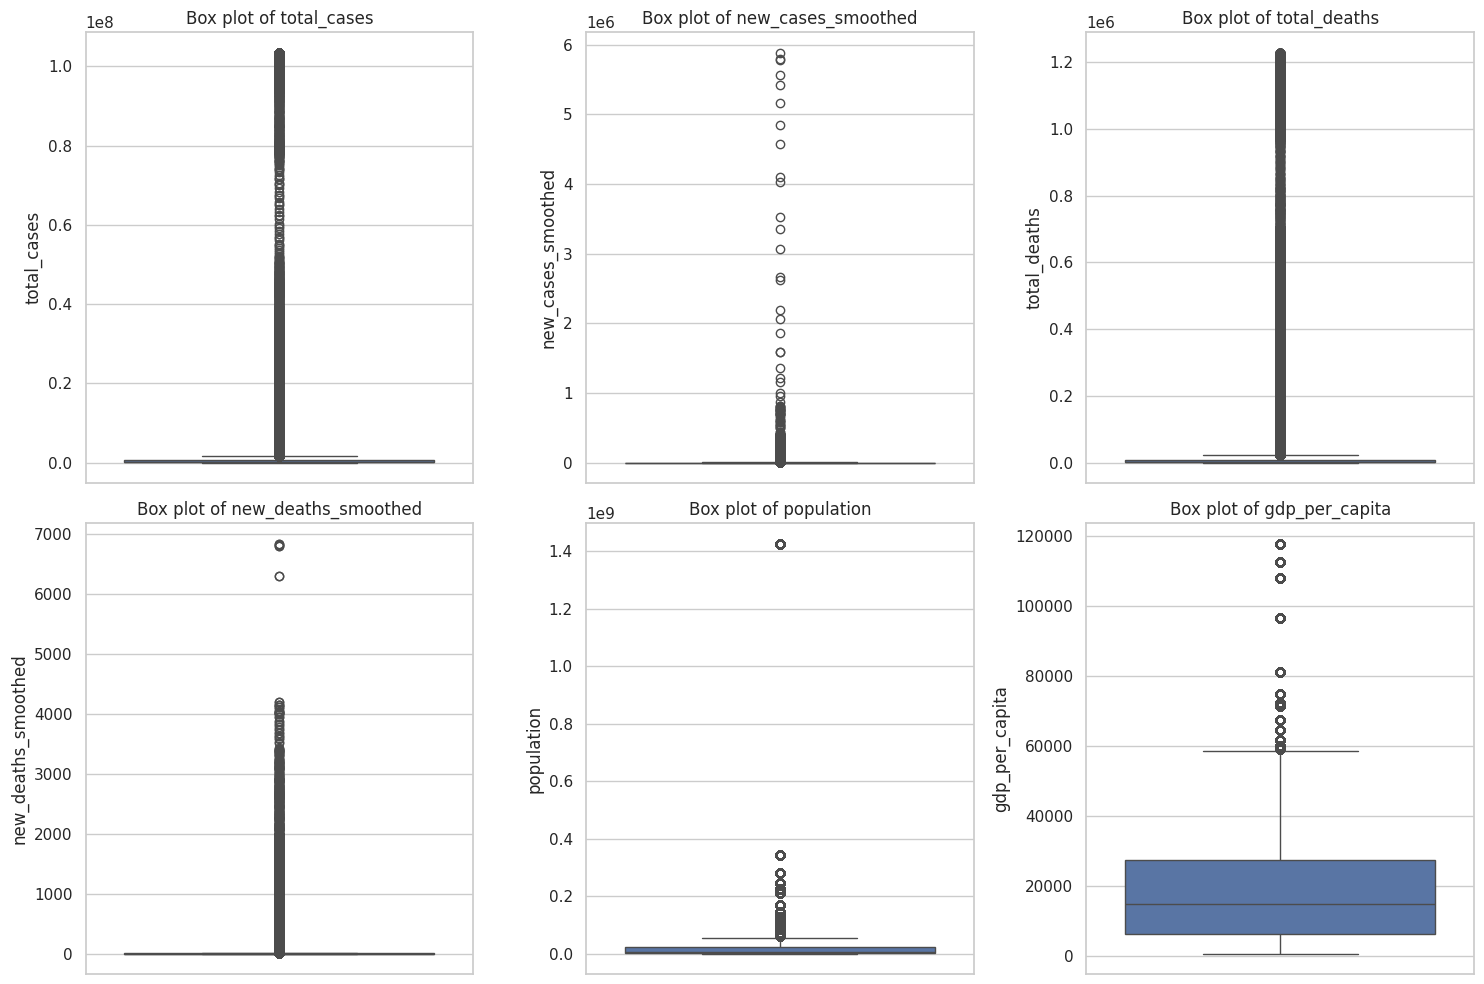

In [ ]:
numerical_cols = df.select_dtypes(include=np.number).columns

# Select a few representative numerical columns for visualization
representative_cols = ['total_cases', 'new_cases_smoothed', 'total_deaths', 'new_deaths_smoothed', 'population', 'gdp_per_capita']

# Generate box plots for the selected columns
plt.figure(figsize=(15, 10))
for i, col in enumerate(representative_cols):
    plt.subplot(2, 3, i + 1)
    sns.boxplot(y=df[col])
    plt.title(f'Box plot of {col}')
plt.tight_layout()
plt.show()

**Reasoning**:
Discuss potential strategies for handling the identified outliers based on the box plots.



In [ ]:
print("Observations from Box Plots and Potential Outlier Handling Strategies:")
print("-" * 70)
print("The box plots for columns like 'total_cases', 'new_cases_smoothed', 'total_deaths', and 'new_deaths_smoothed' show a large number of outliers with very high values. This is expected in pandemic data, where a few countries or regions might have significantly higher case and death counts than others.")
print("\nPotential Strategies for Handling Outliers (without implementation):")
print("1. Capping/Winsorizing: Replace extreme outlier values with a certain percentile value (e.g., 95th or 99th percentile). This can be useful for skewed data where extreme values might disproportionately influence analysis, but it might also obscure genuine variations.")
print("2. Transformation: Apply mathematical transformations like logarithmic or square root transformations to the skewed columns. This can help reduce the impact of outliers by compressing the range of the data, making the distribution more symmetrical.")
print("3. Removal: Remove the rows containing extreme outliers. This is generally not recommended unless there is a strong reason to believe the outlier is due to data entry error or is not representative of the population. Removing data can lead to loss of information and might bias the results.")
print("4. Keep as is: In some cases, especially with real-world data like pandemic statistics, outliers might represent genuine extreme events or conditions. Removing or altering them might lead to a loss of valuable information. The decision to handle outliers depends heavily on the specific analysis being performed.")
print("\nConsidering the nature of the COVID-19 data, where some countries were significantly more affected than others, capping or transformation might be more appropriate than removal, depending on the specific analytical goal. Keeping the outliers as is might also be a valid approach if the analysis aims to understand the full range of the pandemic's impact.")

Observations from Box Plots and Potential Outlier Handling Strategies:
----------------------------------------------------------------------
The box plots for columns like 'total_cases', 'new_cases_smoothed', 'total_deaths', and 'new_deaths_smoothed' show a large number of outliers with very high values. This is expected in pandemic data, where a few countries or regions might have significantly higher case and death counts than others.

Potential Strategies for Handling Outliers (without implementation):
1. Capping/Winsorizing: Replace extreme outlier values with a certain percentile value (e.g., 95th or 99th percentile). This can be useful for skewed data where extreme values might disproportionately influence analysis, but it might also obscure genuine variations.
2. Transformation: Apply mathematical transformations like logarithmic or square root transformations to the skewed columns. This can help reduce the impact of outliers by compressing the range of the data, making the dis

## Summary:

### Data Analysis Key Findings

*   The dataset was successfully loaded, and initial inspection showed the data types and the first few rows. The 'date' column was already in datetime format.
*   Several columns initially had a high percentage of missing values. Columns with over 90% missing data were dropped. Time-series columns had missing values imputed using forward and backward fill within each country group. Remaining missing values in demographic and economic columns were imputed with the median.
*   Inconsistent data entries in the 'country' and 'continent' columns were addressed by removing aggregate entries from the 'country' column and dropping rows with missing 'continent' values.
*   The 'date' column was confirmed to be in the correct datetime format, and other columns had appropriate data types.
*   Box plots of numerical columns revealed numerous high-value outliers in fields like 'total\_cases', 'new\_cases\_smoothed', 'total\_deaths', and 'new\_deaths\_smoothed', which are expected in pandemic data due to variations in impact across regions.

### Insights or Next Steps

*   The cleaning process has significantly improved the data quality by handling missing values and inconsistencies. The presence of expected outliers in pandemic-related metrics has been noted, and the decision on how to handle them will be contingent on the specific analytical goals.
*   Proceed with the planned data analysis or visualization tasks, considering the characteristics of the data, including the identified outliers, and selecting appropriate methods that are robust to their presence or addressing them as required by the analysis.
